In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

hbarc = 197.327053                    #(* [MeV fm] *)
MN0 = (938.27231 + 939.56563)/2       #(* average nucleon mass [MeV] *)
MN  = MN0/hbarc**2			          #(* average nucleon mass in units [1/(MeV fm^2)] *)

print("MN is:",MN)

MN is: 0.02411320030742015


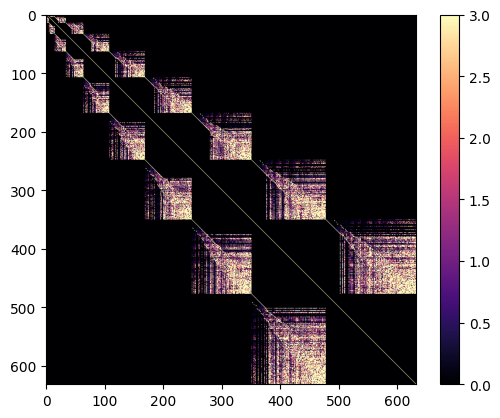

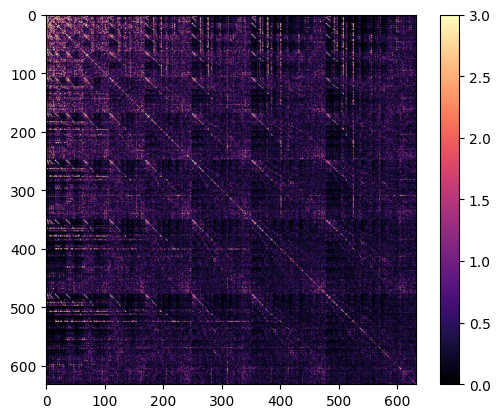

Symmetric? True


In [31]:
TMat = np.loadtxt("kinetic_EMax20_hw20.dat")
VMat = np.loadtxt("chi2b3b_EMax20_hw20.dat")
HMat = TMat + VMat

# display TMat and VMat
plt.imshow(np.abs(TMat), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()
plt.imshow(np.abs(VMat), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()

#rows, cols = HMat.shape
#print(f"Rows: {rows}, Columns: {cols}")

# basic check
print("Symmetric?", np.allclose(HMat, HMat.T))

In [32]:
def commutator(A, B):
    """Return [A, B] = AB - BA."""
    return A @ B - B @ A

EtaMat = commutator(TMat, HMat)

print("Antisymmetric?", np.allclose(EtaMat, -EtaMat.T))

Antisymmetric? True


In [33]:
def wegner_generator(H, T):
    """Wegner generator eta = [T, H]."""
    return commutator(T, H)

def srg_rhs(a, H):
    """Right-hand side of dH/da = MN^2 * [eta, H]"""
    eta = wegner_generator(H, TMat)
    dHda = MN**2 * commutator(eta, H)
    return dHda

# Create an empty SRG evolution storage, with first element VMat (initial value)
VMatSRG = {} 
VMatSRG[0.0] = VMat

a0 = 0.0       #initial value
aDel = 0.0001  #integration step
IntegrationSteps = 200   #takes one minute with 500
MatIndexDistance = aDel * IntegrationSteps #distance between indexes of VMatSRG
NElements = 6

def euler_integration(a):
    HMat = TMat + VMatSRG[a]
    aGrid = np.linspace(a, a + MatIndexDistance, IntegrationSteps + 1)

    for a in aGrid:
        HMatDel = aDel * srg_rhs(a,HMat)
        HMat = HMat + HMatDel
    a = np.round(a, 5)

    VMatSRG[a] = HMat - TMat

for a in np.arange(a0, np.round(a0 + NElements * MatIndexDistance, 5), MatIndexDistance):
    euler_integration(a)

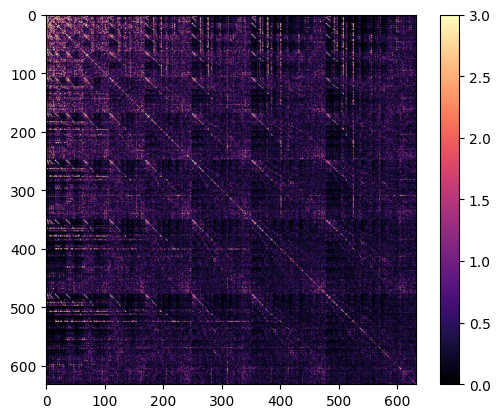

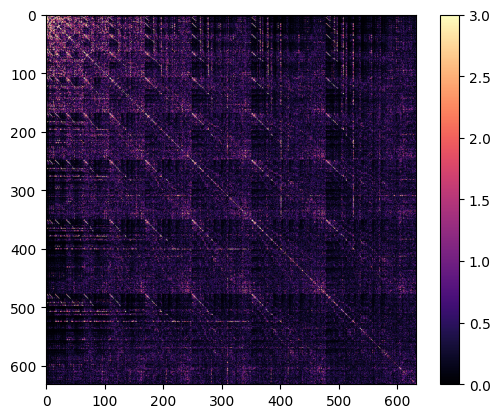

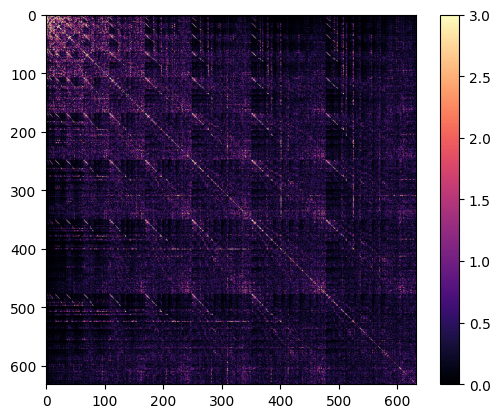

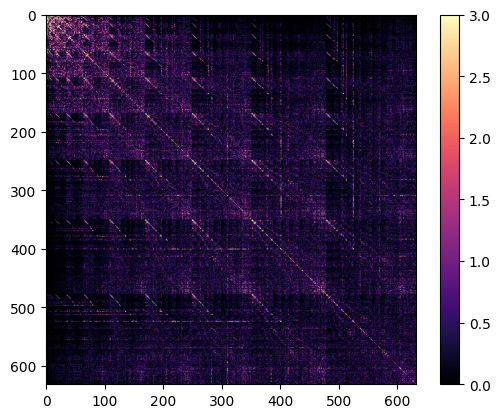

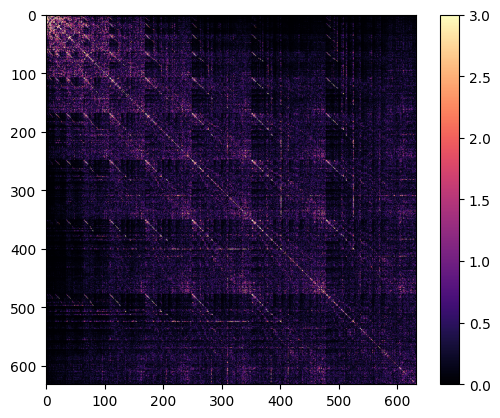

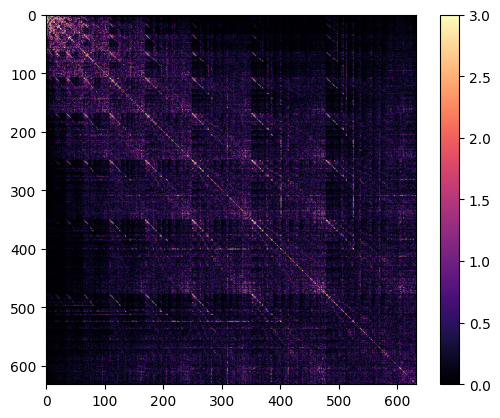

In [34]:
for a in np.arange(a0, np.round(a0 + NElements * MatIndexDistance, 5), MatIndexDistance):
    plt.imshow(np.abs(VMatSRG[a]), vmin=0, vmax=3, cmap="magma")
    plt.colorbar()
    plt.show()

In [35]:
for a in np.arange(a0, np.round(a0 + NElements * MatIndexDistance, 5), MatIndexDistance):
    HMat = TMat + VMatSRG[a]

    Eigenvalues = np.linalg.eigvalsh(HMat)
    FiveLowestMagnitude = Eigenvalues[np.argsort(np.abs(Eigenvalues))[:5]]

    result = np.min(FiveLowestMagnitude)

    print(f"The eigenvalue corresponding to a = {a} is: {result}")

The eigenvalue corresponding to a = 0.0 is: -8.07045774855503
The eigenvalue corresponding to a = 0.02 is: -8.086009780947068
The eigenvalue corresponding to a = 0.04 is: -8.088462521382077
The eigenvalue corresponding to a = 0.06 is: -8.089234051452175
The eigenvalue corresponding to a = 0.08 is: -8.089589139101314
The eigenvalue corresponding to a = 0.1 is: -8.089785561894757


lowest magnitude eigenvalue is changing very slowly with a. That shouldn't happen however we recall we are integrating with Euler's method, so numerical errors can get big.


for a = 0.0
[[2, np.float64(4.30574968946517)], [4, np.float64(1.3882851650109933)], [6, np.float64(-0.9161379698551856)], [8, np.float64(-2.2917404146247096)], [10, np.float64(-4.03651700535846)], [12, np.float64(-5.203300359286622)], [14, np.float64(-6.3613507141854635)], [16, np.float64(-7.1548081891518365)], [18, np.float64(-7.7352532631366255)], [20, np.float64(-8.07045774855503)]]
for a = 0.02
[[2, np.float64(-2.1266223493358716)], [4, np.float64(-4.554621631889416)], [6, np.float64(-6.060426849153217)], [8, np.float64(-6.8260382953292735)], [10, np.float64(-7.51214783395375)], [12, np.float64(-7.781477446855383)], [14, np.float64(-7.950952809867476)], [16, np.float64(-8.003492021598952)], [18, np.float64(-8.022174134884427)], [20, np.float64(-8.086009780947068)]]
for a = 0.04
[[2, np.float64(-4.173084311942589)], [4, np.float64(-6.2119875929161985)], [6, np.float64(-7.261289770070648)], [8, np.float64(-7.654446908116647)], [10, np.float64(-7.939688899766018)], [12, np.float64(-8

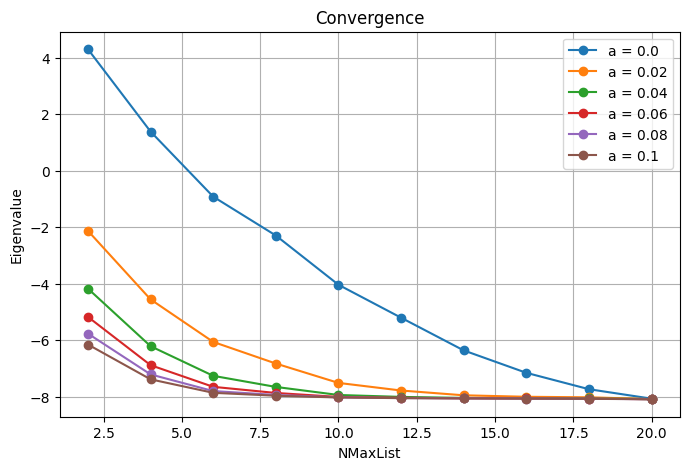

In [37]:
NMaxList = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] #number of states corresponding to the submatrices below
DimList = [5, 15, 34, 64, 108, 169, 249, 351, 478, 632] #size of the submatrices
EEList = {}

for a in np.arange(a0, np.round(a0 + NElements * MatIndexDistance, 5), MatIndexDistance):
    print(f"for a = {a}")
    EEList[a] = []
    for i in range(len(NMaxList)):
        HMat = TMat + VMatSRG[a]
        SubHMat = HMat[:DimList[i], :DimList[i]]
        eigenvalues = np.linalg.eigvalsh(SubHMat) 
        EE0 = eigenvalues[0] # eigenvalues is in ascending order, thus it picks min
        EEList[a].append([NMaxList[i], EE0])
    print(EEList[a])

plt.figure(figsize=(8, 5))
for a in np.arange(a0, np.round(a0 + NElements * MatIndexDistance, 5), MatIndexDistance):
    x, y = zip(*EEList[a])
    plt.plot(x, y, label=f"a = {a}",  marker='o')
plt.xlabel("NMaxList")
plt.ylabel("Eigenvalue")
plt.title("Convergence")
plt.legend()
plt.grid(True)
plt.show()
